In [1]:
from matplotlib import pyplot as plt
import pandas as pd
from surrogate import SurrogateAutoMLModel
from surrogate import SurrogateTabPFN
from tabpfn_extensions.interpretability.shap import *
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['font.size'] = 12

df = pd.read_csv('water_tank_exps.csv')

In [2]:
#amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
#tmodel = SurrogateTabPFN(time_budget=None)amodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])
#tmodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])
#
#amodel.save_model('amodel.pkl')
#tmodel.save_model('tmodel.pkl')
amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
tmodel = SurrogateTabPFN(time_budget=None)

In [3]:
amodel.load_model('amodel.pkl'), tmodel.load_model('tmodel.pkl')

(AutoML(append_log=False, auto_augment=True, custom_hp={},
        cv_score_agg_func=None, early_stop=False, ensemble=False,
        estimator_list='auto', eval_method='auto', fit_kwargs_by_estimator={},
        force_cancel=False, free_mem_ratio=0, hpo_method='auto',
        keep_search_state=False, learner_selector='sample', log_file_name='',
        log_training_metric=False, log_type='better', max_iter=None,
        mem_thres=4294967296, metric='auto', metric_constraints=[],
        min_sample_size=10000, mlflow_logging=True, model_history=False,
        n_concurrent_trials=1, n_jobs=-1, n_splits=5, pred_time_limit=inf,
        preserve_checkpoint=True, retrain_full=True, ...),
 TabPFNRegressor())

In [4]:
tshap_values=get_shap_values(tmodel, df[['action_mode', 'tg_threshold', 'water_tank_size']])
ashap_values=get_shap_values(amodel, df[['action_mode', 'tg_threshold', 'water_tank_size']])

ExactExplainer explainer: 401it [01:38,  3.77it/s]                         


In [5]:
var_dict = {
    'action_mode': '$\\alpha$',
    'tg_threshold': "$T_{\\mathrm{max}}$ [°C]",
    'water_tank_size': "N [mm]"
}

def plot_size_legend(smax, ax, title, loc=False, shap=False):
    # 添加大小图例
    sizes = [ smax* 0.1, smax]
    labels = [f"{size}" for size in sizes]
    handles = [
        plt.scatter([], [], s=size, color="gray", label=label) for size, label in zip(sizes, labels)
    ]
    
    if title == 'RWT size [mm]':
        loc = "upper right" if not loc else loc
        ncol = 2
    else:
        loc = "best"
        ncol = 1
    if shap:
        legend = ax.legend(
        handles=handles,
        title=title,
        loc=loc,
        scatterpoints=1,
        frameon=True,
        ncol=ncol, 
    )
    else:
        legend = ax.legend(
        handles=handles,
        title=title,
        loc=loc,
        scatterpoints=1,
        frameon=True,
        ncol=ncol, 
        bbox_to_anchor=(1.02, 1)
    )
    ax.add_artist(legend)
    
def plot_bar_labels(ax, bars, labels):
    for bar, label in zip(bars, labels):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
        )

def plot_raw(df, ax):
    p = ax.scatter(df['action_mode'], df['tg_threshold'], c=df['urbac'], 
                   cmap='viridis', 
                   #cmap=plt.get_cmap("rainbow"),
                   s=df['water_tank_size'], alpha=0.9, 
                   linewidths=0.5, 
                   #edgecolors='k',
                   edgecolors='none',
                   )
    ax.set_ylim(df['tg_threshold'].min()-1, df['tg_threshold'].max())
    cax = ax.inset_axes([1.02, 0, 0.05, 0.8], transform=ax.transAxes)
    cbar = plt.colorbar(p, pad=0.01, aspect=60, shrink=1, 
                        location='right', ax=cax)
    cax.axis('off')  # 隐藏颜色条的坐标轴
    cbar.set_label('$E_{\\mathrm{AC}}$ [MWh]')
    #ax.legend(['Water tank size'], loc='upper right')
    plot_size_legend(df['water_tank_size'].max().round(0), ax, var_dict['water_tank_size'])

    #ax.set_xlabel('SI')
    #ax.set_ylabel('T$_{\\mathrm{max}}$ [°C]')
    ax.set_xlabel(var_dict['action_mode'])
    ax.set_ylabel(var_dict['tg_threshold'])
    ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)
    
def plot_surrogate_performance(df, ax):
    df_plot = df[['flod', 'model', 'MAE', 'RMSE']].melt(id_vars=['flod', 'model'], value_vars=['MAE', 'RMSE'])
    cmap = plt.get_cmap("rainbow", 2)  
    palette = [cmap(i) for i in range(cmap.N)] 
    sns.barplot(x='variable', y='value', hue='model', data=df_plot, ax=ax, ci='sd', 
                palette=palette, alpha=0.65, linewidth=1, edgecolor='k')
    ax.legend(frameon=False)
    #plot_bar_labels(ax, ax.patches, df_plot['value'].round(2))

def plot_sactter_shap(shap_values, xvar, cvar, svar, ax, loc=False):
    # or you need more flexible customization
    scatter = ax.scatter(
        shap_values[:, xvar].data,
        shap_values[:, xvar].values,
        c=shap_values[:, cvar].data,
        #smarker="^",
        s=shap_values[:, svar].data,
        #cmap=plt.get_cmap("rainbow"),
        cmap='viridis',
        rasterized=True,
        zorder=5,
        alpha=0.7,
        linewidths=0.5,
        #edgecolors="k",
        edgecolors="none",
    )

    cbar = plt.colorbar(scatter, format="%2.1f", pad=0.02, aspect=30, shrink=0.6,
                        #方向和位置
                        orientation='horizontal', location='top', 
                        )
    cbar.set_label(var_dict[cvar], 
                   # 位置设置在右边
                   loc='center',
                    #字体大小
                    fontsize=10
                   )
    #设置颜色条的刻度标签字体大小
    cbar.ax.tick_params(labelsize=10)
    #cbar.outline.set_visible(False)
    smax = max(shap_values[:, svar].data).round(0) 
    plot_size_legend(smax, ax, var_dict[svar], loc='best', shap=True)

    ax.set_xlabel(var_dict[xvar])
    ax.set_ylabel(f"SHAP value ({var_dict[xvar].split(' [')[0]})")

    ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)
    
def plot_mean_shap_values(tshap_values, ashap_values, ax):
    
    df_shap1 = pd.DataFrame()
    df_shap1['feature'] = ['action_mode', 'tg_threshold', 'water_tank_size']
    df_shap1['shap_value'] = tshap_values.abs.mean(axis=0).values
    df_shap1['model'] = 'TabPFN'
    
    df_shap2 = pd.DataFrame()
    df_shap2['feature'] = ['action_mode', 'tg_threshold', 'water_tank_size']
    df_shap2['shap_value'] = ashap_values.abs.mean(axis=0).values
    df_shap2['model'] = 'AutoML'
    
    df_shap = pd.concat([df_shap2, df_shap1]).rename(columns={'shap_value': 'Mean |SHAP value|'}).replace(var_dict)
    
    display(df_shap)
    
    cmap = plt.get_cmap("rainbow", 2)  
    palette = [cmap(i) for i in range(cmap.N)] 
    p = sns.barplot(x='Mean |SHAP value|', y='feature', hue='model', data=df_shap, 
                    linewidth=1, edgecolor='k',
                    ax=ax, palette=palette, alpha=0.65)
    
    #plot_bar_labels(ax, ax.patches, df_shap['Mean |SHAP value|'].round(2))
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[4:6], labels=labels[4:6], frameon=False)
    

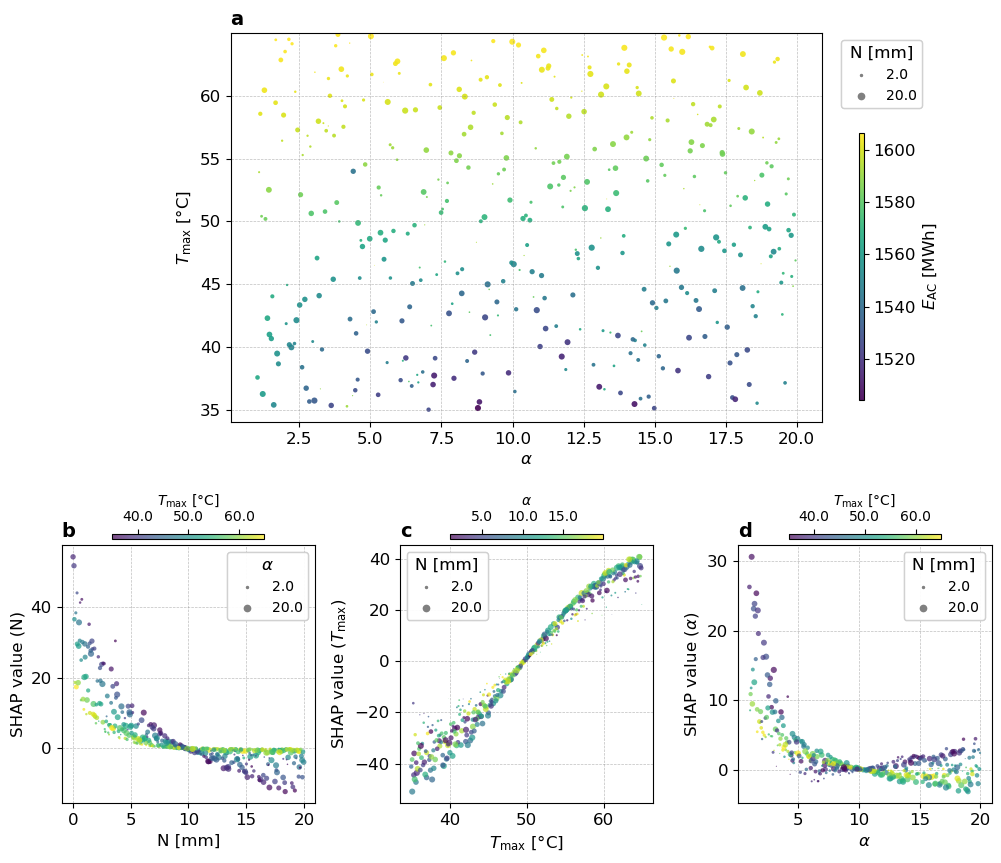

In [6]:
#fig, axs = plt.subplots(tight_layout=True, figsize=(12, 10), ncols=2, nrows=2)
#axs = axs.flatten()
# 设计4个子图，第一个上列，第二个下列，第三个右列，第四个左列
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 10))
# 将网格切分为 2行 6列
gs = gridspec.GridSpec(2, 6, height_ratios=[1, 0.8], hspace=0.2, wspace=1)

# 第一幅图居中，占据中间的两列 (索引 2 和 3，也就是 [2:4])
ax1 = fig.add_subplot(gs[0, 1:5]) 

# 下面三幅图，每幅占据两列，平分底部的空间
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
ax4 = fig.add_subplot(gs[1, 4:6])

axs = [ax1, ax2, ax3, ax4]
plot_raw(df, axs[0])
#df_p = pd.read_csv('surrogate_compare_res.csv')
#display(df_p.groupby('model').mean())
#display(df_p.groupby('model').std())
#plot_surrogate_performance(df_p, axs[1])
#axs[1].set_xlabel('')
#axs[1].set_ylabel('Value [W/m$^2$]')

#plot_sactter_shap(tshap_values, 'action_mode', 'tg_threshold', 'water_tank_size', axs[2])
plot_sactter_shap(tshap_values, 'water_tank_size', 'tg_threshold', 'action_mode', axs[1])
plot_sactter_shap(tshap_values, 'tg_threshold', 'action_mode',  'water_tank_size', axs[2], loc='best')
plot_sactter_shap(tshap_values, 'action_mode', 'tg_threshold', 'water_tank_size', axs[3])
#plot_mean_shap_values(tshap_values, ashap_values, axs[3])
#labels = [  i.get_text().split(" [")[0]  for i in axs[3].get_yticklabels()]
#axs[3].set_yticklabels(labels, rotation=90, ha='center', va='center')
#axs[3].set_ylabel('')

titles = ['a', 'b', 'c', 'd']
for ax, title in zip(axs, titles):
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figs/water_tank_exps.pdf', dpi=300, bbox_inches='tight')
plt.show()

,flod,MAE,RMSE,R2,MAPE
model,,,,,
AutoML,4.5,2.203171,3.743887,0.974759,0.001408
TabPFN,4.5,0.536411,1.741368,0.985830,0.000342


,flod,MAE,RMSE,R2,MAPE
model,,,,,
AutoML,3.02765,0.474174,1.527827,0.022765,0.000302
TabPFN,3.02765,0.474659,2.558044,0.029643,0.000304


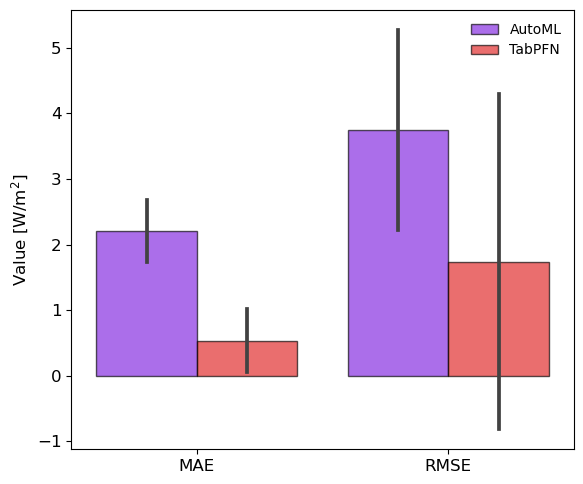

,feature,Mean |SHAP value|,model
0,$\alpha$,2.181973,AutoML
1,$T_{\mathrm{max}}$ [°C],20.094415,AutoML
2,N [mm],6.779941,AutoML
0,$\alpha$,2.531083,TabPFN
1,$T_{\mathrm{max}}$ [°C],21.776635,TabPFN
2,N [mm],5.807048,TabPFN


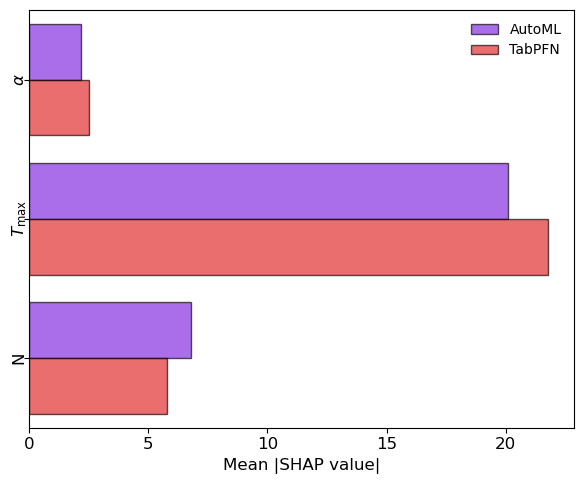

In [7]:
fig, ax = plt.subplots(tight_layout=True, figsize=(6, 5))
df_p = pd.read_csv('surrogate_compare_res.csv')
display(df_p.groupby('model').mean())
display(df_p.groupby('model').std())
plot_surrogate_performance(df_p, ax)
ax.set_xlabel('')
ax.set_ylabel('Value [W/m$^2$]')
fig.savefig('../data/figs/surrogate_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(tight_layout=True, figsize=(6, 5))
plot_mean_shap_values(tshap_values, ashap_values, ax)
labels = [  i.get_text().split(" [")[0]  for i in ax.get_yticklabels()]
ax.set_yticklabels(labels, rotation=90, ha='center', va='center')
ax.set_ylabel('')
fig.savefig('../data/figs/mean_shap_values.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
#fig, axs = plt.subplots(tight_layout=True, figsize=(10, 5))
#plot_sactter_shap(tshap_values, 'tg_threshold', 'action_mode',  'water_tank_size', axs, loc='best')
#plt.savefig('../data/figs/water_tank_exps_shap_tg.pdf', dpi=300, bbox_inches='tight')
#
#fig, axs = plt.subplots(tight_layout=True, figsize=(10, 5))
#plot_sactter_shap(tshap_values, 'action_mode', 'tg_threshold', 'water_tank_size', axs)
#plt.savefig('../data/figs/water_tank_exps_shap_SI.pdf', dpi=300, bbox_inches='tight')